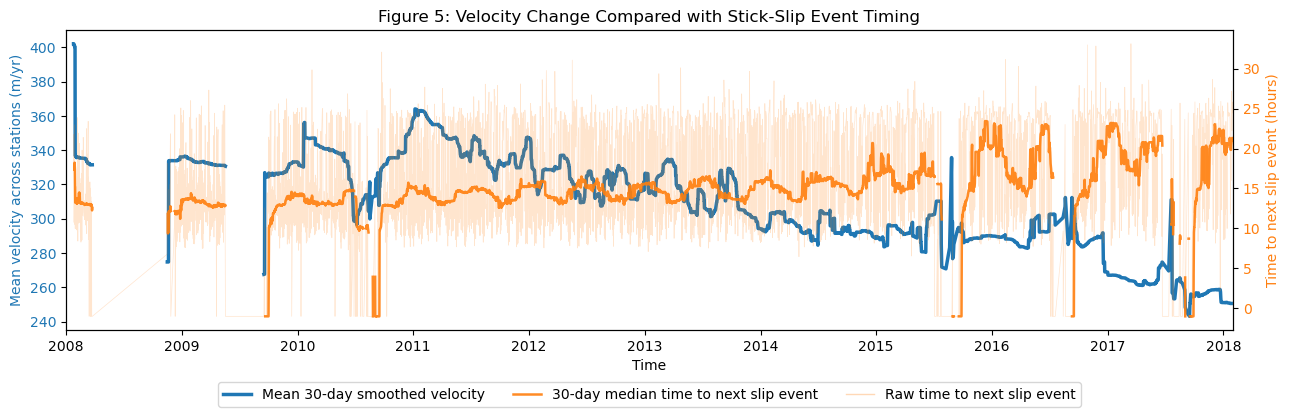

In [1]:

# Figure 5: Velocity vs stick-slip event timing


import pandas as pd
import matplotlib.pyplot as plt


# Load velocity data


vel_df = pd.read_csv(
    "../Data/whillans_events_with_velocity(in).csv",
    parse_dates=["start_time"]
)

vel_df = vel_df.sort_values("start_time").reset_index(drop=True)

# Keep only data through 2018
vel_df = vel_df[vel_df["start_time"].dt.year <= 2018].copy()

# Find all 30-day smoothed velocity columns
v30d_cols = [c for c in vel_df.columns if c.startswith("v30d_")]

# Compute mean 30-day smoothed velocity across all available stations
vel_df["mean_velocity_30d"] = vel_df[v30d_cols].mean(axis=1, skipna=True)

# Break velocity line across large gaps so matplotlib does not draw connecting lines
vel_df["time_gap_days"] = vel_df["start_time"].diff().dt.days

vel_df.loc[
    vel_df["time_gap_days"] > 45,
    "mean_velocity_30d"
] = pd.NA


# Load time-to-next-event data


event_df = pd.read_csv(
    "../Data/filtered_time_to_next_event.csv",
    parse_dates=["ev_time_utc"]
)

event_df = event_df.sort_values("ev_time_utc").reset_index(drop=True)

# Align time range between datasets


start_time = vel_df["start_time"].min()
end_time = vel_df["start_time"].max()


# Filter event data to only include up to 2018
event_df = event_df[
    (event_df["ev_time_utc"] >= pd.Timestamp("2008-01-01")) &
    (event_df["ev_time_utc"] <= pd.Timestamp("2018-01-31"))
].copy()

# Smooth time-to-next-event data

# Set event time as index so we can use a time-based rolling window
event_df = event_df.set_index("ev_time_utc").sort_index()

# because raw event timing is noisy, use 30-day rolling median
event_df["time_to_next_30d"] = (
    event_df["time_to_next_ev_hr"]
    .rolling("30D", min_periods=5)
    .median()
)

# Put event time back as column
event_df = event_df.reset_index()

# Break event line across large gaps so it does not connect unrelated periods
event_df["event_gap_hours"] = (
    event_df["ev_time_utc"].diff().dt.total_seconds() / 3600
)

event_df.loc[
    event_df["event_gap_hours"] > 48,
    "time_to_next_30d"
] = pd.NA



# Make Figure 5


fig, ax1 = plt.subplots(figsize=(13, 5))


# Left y-axis: mean 30-day velocity


line1 = ax1.plot(
    vel_df["start_time"],
    vel_df["mean_velocity_30d"],
    color="tab:blue",
    linewidth=2.5,
    label="Mean 30-day smoothed velocity"
)

ax1.set_xlabel("Time")
ax1.set_ylabel("Mean velocity across stations (m/yr)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")



# Right y-axis: time to next slip event


ax2 = ax1.twinx()

# faint raw event timing for context
line3 = ax2.plot(
    event_df["ev_time_utc"],
    event_df["time_to_next_ev_hr"],
    color="tab:orange",
    alpha=0.2,
    linewidth=0.5,
    label="Raw time to next slip event"
)

# Main smoothed event timing line
line2 = ax2.plot(
    event_df["ev_time_utc"],
    event_df["time_to_next_30d"],
    color="tab:orange",
    linewidth=1.8,
    alpha=0.9,
    label="30-day median time to next slip event"
)

ax2.set_ylabel("Time to next slip event (hours)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")


# Title, legend, and x-axis limits


ax1.set_title("Figure 5: Velocity Change Compared with Stick-Slip Event Timing")

lines = line1 + line2 + line3
labels = [line.get_label() for line in lines]

# Force both y-axes to share same x-axis range
ax1.set_xlim(pd.Timestamp("2008-01-01"), pd.Timestamp("2018-01-31"))
ax2.set_xlim(pd.Timestamp("2008-01-01"), pd.Timestamp("2018-01-31"))

# Put legend below plot
legend = ax1.legend(
    lines,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=True
)

for legline, label in zip(legend.get_lines(), labels):
    if label == "Raw time to next slip event":
        legline.set_linewidth(1.0)
        legline.set_alpha(0.3)


# Leave room at bottom for legend
plt.tight_layout(rect=[0, 0.12, 1, 1])

plt.savefig(
    "../images/figure5_velocity_vs_event_timing_clean_2018.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### Figure 5 Interpertation: 

Figure 5 compares changes in mean ice velocity with the timing between stick-slip events from 2008 to 2018. The blue line shows the mean 30-day smoothed velocity across all stations, while the orange line shows the 30-day median time to the next slip event. The lighter orange lines represent the raw event timing data, which is much more variable.

Overall, there is a noticeable inverse relationship between velocity and event timing. When the ice velocity is relatively high (around 2010–2012), the time between slip events tends to be shorter, indicating more frequent stick-slip behavior. As velocity gradually decreases after about 2013, the time between events generally increases, meaning slip events become less frequent. This pattern suggests that faster-moving ice is associated with more frequent slip events, while slower-moving ice corresponds to longer intervals between events.

The smoothed lines make this relationship easier to see by reducing short-term variability, while the raw data highlights how noisy the event timing can be on an individual basis. Although the relationship is not perfectly consistent at all times, the overall trend supports the idea that changes in ice velocity are linked to changes in stick-slip event frequency across the Whillans Ice Plain.